## Libraries

In [4]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import math
import numpy as np

## Linking Functions notebook

In [5]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [6]:
# Importing relevant functions
import importlib
from functions import get_len, get_count, get_area, get_add_from_cum, semi_norm_mix_transform, wrap_api_query, generate_measure_sample_plot

## Extracting areas
https://boundingbox.klokantech.com/

In [7]:
# Extract bounding boxes
bboxes_dict = {'strasburg' : '7.3233,48.2606,8.2281,48.9394',
          'paris' : '2.012585,48.656288,2.745923,49.064658',
          'london' : '-0.5953,51.2282,0.3399,51.7243',
          'iceland' : '-25.88,63.02,-11.95,66.93',
          'fiji' : '176.35,-19.9,-178.0,-15.73',
          'new zealand' : '164.75,-47.68,179.16,-34.01',
          'madagascar' : '42.54,-26.06,51.2,-10.86',
          'suriname' : '-58.25,1.72,-53.7,6.52',
          'maraba (brasil)' : '-49.295,-5.4587,-48.9132,-5.1879',
          'south dakota' : '-104.07,42.88,-96.27,46.08',
          'dushanbe (tajikistan)' : '68.2517,37.2365,69.3235,39.0445',
          'dubai' : '54.88,24.8444,55.7785,25.492',
          'bahrain' : '50.3262,25.7656,50.7699,26.4082',
          'burundi' : '28.53,-4.84,31.06,-2.17',
          'portugal' : '-9.62,36.98,-6.22,42.16',
          'lisbon' : '-9.6267,38.3193,-8.6297,39.0632',
          'braganaca (n. portugal)' : '-7.5187,41.1975,-6.5217,41.9108'}

In [8]:
# Convert coordinates to dataframe for iterating
bboxes = pd.DataFrame.from_dict(bboxes_dict, orient='index').reset_index()
bboxes = bboxes.rename(columns={'index' : 'place', 0 : 'bbox'})

In [9]:
bboxes

,place,bbox
0,strasburg,"7.3233,48.2606,8.2281,48.9394"
1,paris,"2.012585,48.656288,2.745923,49.064658"
2,london,"-0.5953,51.2282,0.3399,51.7243"
3,iceland,"-25.88,63.02,-11.95,66.93"
4,fiji,"176.35,-19.9,-178.0,-15.73"
5,new zealand,"164.75,-47.68,179.16,-34.01"
6,madagascar,"42.54,-26.06,51.2,-10.86"
7,suriname,"-58.25,1.72,-53.7,6.52"
8,maraba (brasil),"-49.295,-5.4587,-48.9132,-5.1879"
9,south dakota,"-104.07,42.88,-96.27,46.08"


In [10]:
# Update wrapper function
def wrap_api_query(row, query, filter='type:way and highway=*', time='2008-01-01/2025-01-01/P1M'):
    '''
    A wrapper function to implement API queries on a dataset rowwise. The function keeps identifier columns per each extracted data, i.e. the index in the original dataframe, the event type and the percentage of said event in the bounding box.
    
    Dependencies:
    * pandas
    '''
    # Implement API extract function
    if query == 'count':
        df = get_count(row['bbox'], filter=filter, time=time)
    elif query == 'length':
        df = get_len(row['bbox'], filter=filter,time=time)
    elif query == 'area':
        df = get_area(row['bbox'], filter=filter,time=time)
    else:
        raise ValueError(f"Unknown query type: {query}")
    
    # Append identifier columns
    df['idx'] = row.name # one-to-one index
    df['place'] = row['place'] # place

    return df

In [50]:
# Use wrapper function to extract road counts for all subset rows
counts_rds = pd.concat(
    bboxes.apply(lambda row: wrap_api_query(row, query='count'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract road lengths for all subset rows
lengths = pd.concat(
    bboxes.apply(lambda row: wrap_api_query(row, query='length'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract road counts for all subset rows
counts_bld = pd.concat(
    bboxes.apply(lambda row: wrap_api_query(row, query='count', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract building areas for all subset rows
areas = pd.concat(
    bboxes.apply(lambda row: wrap_api_query(row, query='area', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengths
Succesfully extracted lengt

In [52]:
# Save to files for later loading without computational effort
counts_rds.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\road_counts_new_areas.csv', index=False)
lengths.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\road_lengths_new_areas.csv', index=False)
counts_bld.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\building_counts_new_areas.csv', index=False)
areas.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\building_areas_new_areas.csv', index=False)

In [12]:
counts_rds = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\3) validity\road_counts_new_areas.csv')
lengths = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\3) validity\road_lengths_new_areas.csv')
counts_bld = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\3) validity\building_counts_new_areas.csv')
areas = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\3) validity\building_areas_new_areas.csv')

## Tests

In [13]:
# Test for lists for plots
roads_test = []
bldgs_test = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group, alpha=0.1, return_full=True)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group, alpha=0.1, return_full=True)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test.append(t2)

Data incomplete
Data incomplete
Data incomplete
Data incomplete
Data incomplete
Data incomplete
Polygon 80% saturated at 2010-05-01 00:00:00+00:00
Data incomplete
Polygon 80% saturated at 2011-09-01 00:00:00+00:00
Data incomplete
Data incomplete
Data incomplete
Data incomplete
Polygon 80% saturated at 2019-06-01 00:00:00+00:00
Data incomplete
Data incomplete
Polygon 80% saturated at 2015-06-01 00:00:00+00:00
Polygon 80% saturated at 2009-07-01 00:00:00+00:00
Polygon 80% saturated at 2010-05-01 00:00:00+00:00
Polygon 80% saturated at 2012-03-01 00:00:00+00:00
Data incomplete
Polygon 80% saturated at 2012-06-01 00:00:00+00:00
Polygon 80% saturated at 2013-05-01 00:00:00+00:00
Polygon 80% saturated at 2013-04-01 00:00:00+00:00
Data incomplete
Polygon 80% saturated at 2013-08-01 00:00:00+00:00
Polygon 80% saturated at 2012-07-01 00:00:00+00:00
Polygon 80% saturated at 2017-03-01 00:00:00+00:00
Polygon 80% saturated at 2017-07-01 00:00:00+00:00
Polygon 80% saturated at 2016-10-01 00:00:00+0

## Plots

In [94]:
# Function to create plots for samples
def generate_measure_sample_plot(df_list,
                                 subtitle='incomplete roads data | complete building data\n(large scale events, alpha = 0.1)',
                                 n=6,
                                 length=True,
                                 logscale=True):
    '''
    Function to create a subsample plot of features.
    It allows for any number of plots, but iterates by default on 6, and all margins fit this display.
    The function enables to choose two parameters to modify the output:

    1. length / area: if `length` is defined true (default), the plot will update the axis and column labels to show road lengths; if defined false, these labels will be for building area in sq. meters.
    2. log scale / original scale: if `logscale` is defined true (default), the count and size values will be transformed using a log function; if false, it will keep the original scale.
    
    Dependencies:
    * pandas as pd
    * matplotlib.pyplot as plt
    * matplotlib.dates as mdates
    * matplotlib.lines import Line2D
    '''
    # General parameters
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(20, 24))

    # Column titles in plot
    if length:
        column_titles = ['Length (meter) per count percentage', 'Feature Count', 'Feature Length']
    else:
        column_titles = ['Area (sq. meter) per count percentage', 'Feature Count', 'Feature Length']

    # Plot
    for i, df in enumerate(df_list[0:n]):
        for j in range(3):
            ax = axes[i, j]
            # Plot 1: saturation percentage
            if j == 0:
                # Saturated values:
                if 'percentage_until_saturation' in df.columns:
                    sat = (df['percentage_until_saturation'] >= 0.8).idxmax()
                    df_plt = df.iloc[:sat + 1]
                    ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g')

                    # Adding saturation point
                    saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
                    ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
                    ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                                xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

                # Un-saturated values:      
                else:
                    ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r')
                ax.set_ylabel('Transformed Value', weight='bold')
                if i == (n-1):
                    # Only bottom of each column
                    ax.set_xlabel('Timestamp', weight='bold')
                ax.tick_params(axis='x', rotation=45)
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
                ax.grid(True)

            # Plot 2: feature counts
            elif j == 1:
                if logscale:
                    ax.plot(df['timestamp'], np.log(df['count']), linestyle='-', color='b')
                    ax.set_ylabel('Count (cumulative, log scale)', weight='bold')
                else:
                    ax.plot(df['timestamp'], df['count'], linestyle='-', color='b')
                    ax.set_ylabel('Count (cumulative)', weight='bold')
                if i == (n-1):
                    # Only bottom of each column
                    ax.set_xlabel('Timestamp', weight='bold')
                ax.tick_params(axis='x', rotation=45)
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
                ax.grid(True)

            # Plot 3: feature lengths
            elif j == 2:
                if logscale:
                    ax.plot(df['timestamp'], np.log(df['size']), linestyle='-', color='purple')
                    if length:
                        ax.set_ylabel('Length (cumulative, log scale)', weight='bold')
                    else:
                        ax.set_ylabel('Area (cumulative, log scaled)', weight='bold')
                else:
                    ax.plot(df['timestamp'], df['size'], linestyle='-', color='purple')
                    if length:
                        ax.set_ylabel('Length (cumulative)', weight='bold')
                    else:
                        ax.set_ylabel('Area (cumulative)', weight='bold')
                if i == (n-1):
                    # Only bottom of each column
                    ax.set_xlabel('Timestamp', weight='bold')
                ax.tick_params(axis='x', rotation=45)
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
                ax.grid(True)
        
            # Set titles per each column
            if i == 0:
                axes[0, j].set_title(column_titles[j], fontsize=18, fontweight = 'bold')

    # Set legend
    if length:
        legend_elements = [
            Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
            Line2D([0], [0], color='purple', lw=2, label='Cumulative feature lengths'), 
            Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
            Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
            Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
        ]
    
    else:
        legend_elements = [
            Line2D([0], [0], color='b', lw=2, label='Cumulative feature count'),
            Line2D([0], [0], color='purple', lw=2, label='Cumulative feature areas'), 
            Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (area / count)'),
            Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
            Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
        ]

    legend = fig.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=5,
        bbox_to_anchor=(0.5, -0.005),
        fontsize=12,
        frameon=True,
        title='Legend',
        title_fontsize=13
    )

    legend.get_frame().set_edgecolor('black')
    legend.get_title().set_fontweight('bold')

    # Assign title
    if length:
        fig.text(0.5, 1, f'Mixed Semi-normalized Transform for Road lengths (meter) Cumulative Addition', fontsize=24, fontweight='bold', ha='center')
    else:
        fig.text(0.5, 1, f'Mixed Semi-normalized Transform for Building areas (sq. meter) Cumulative Addition', fontsize=24, fontweight='bold', ha='center')
    fig.text(0.5, 0.97, subtitle, fontsize=20, fontweight='normal', ha='center')

    # Arrange layout
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Show plots
    plt.show()

    # Return the figure to a variable
    return fig

In [81]:
list(bboxes_dict.keys())[6:12]

['madagascar',
 'suriname',
 'maraba (brasil)',
 'south dakota',
 'dushanbe (tajikistan)',
 'dubai']

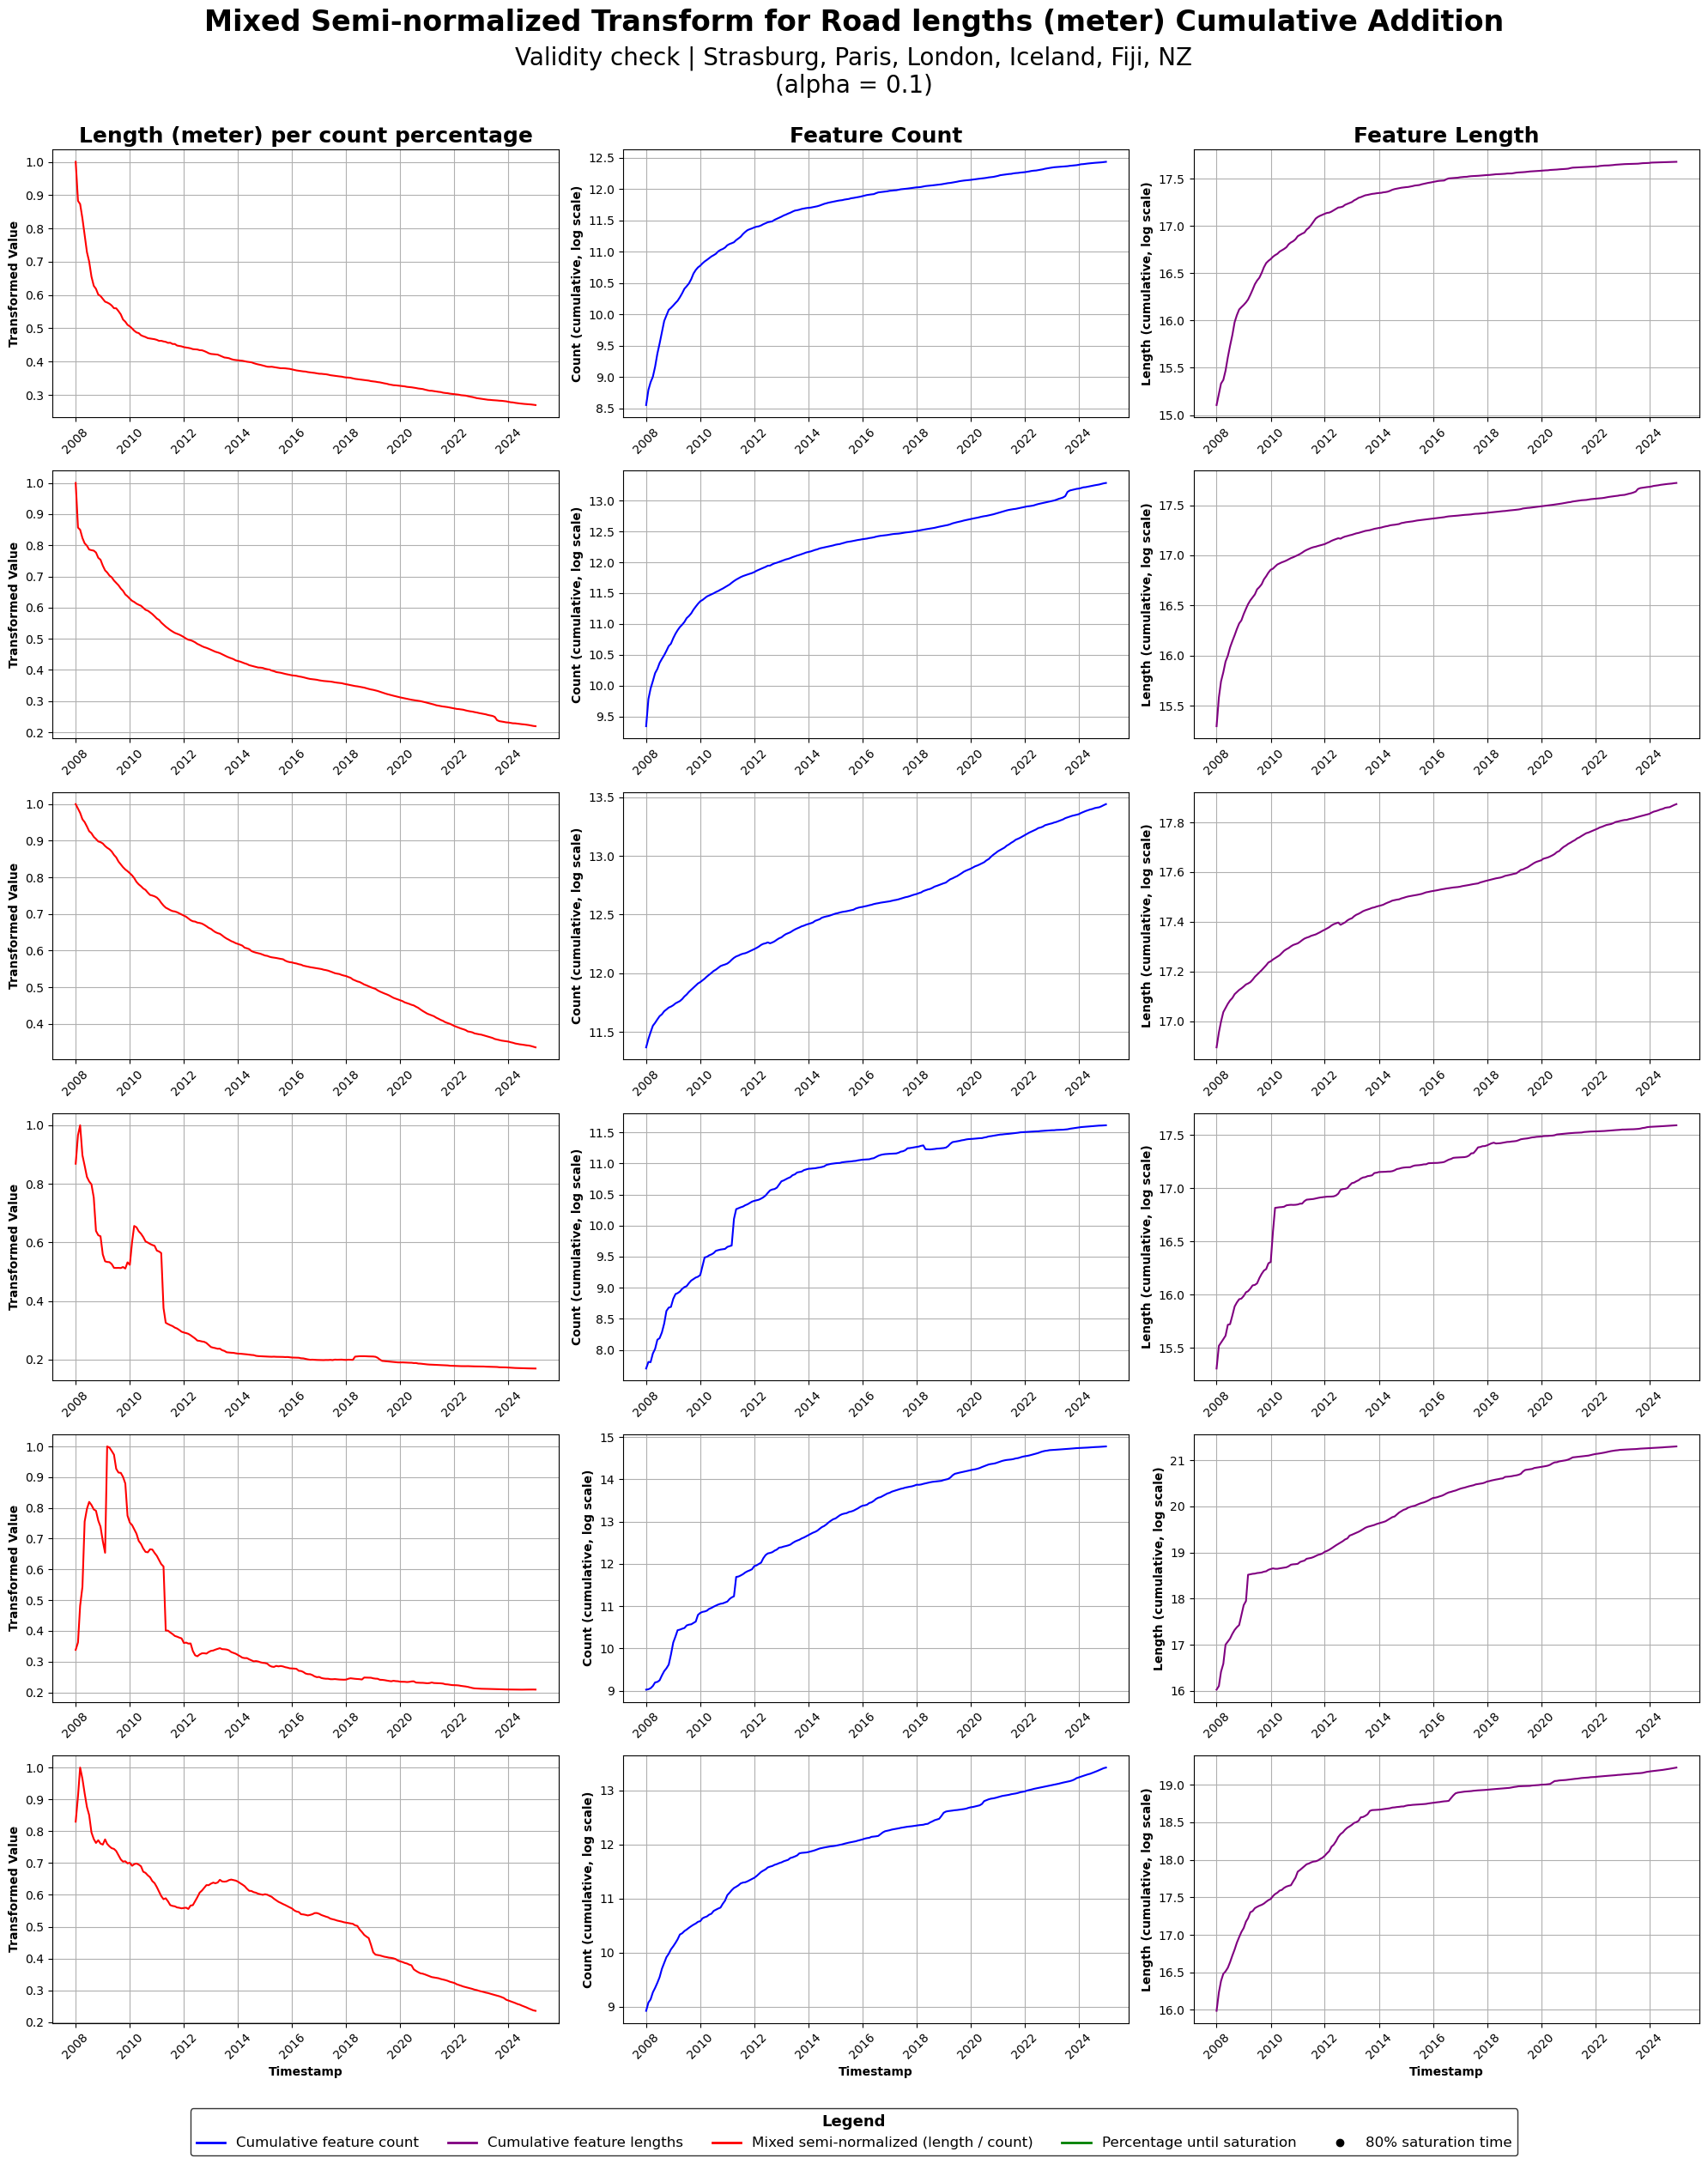

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


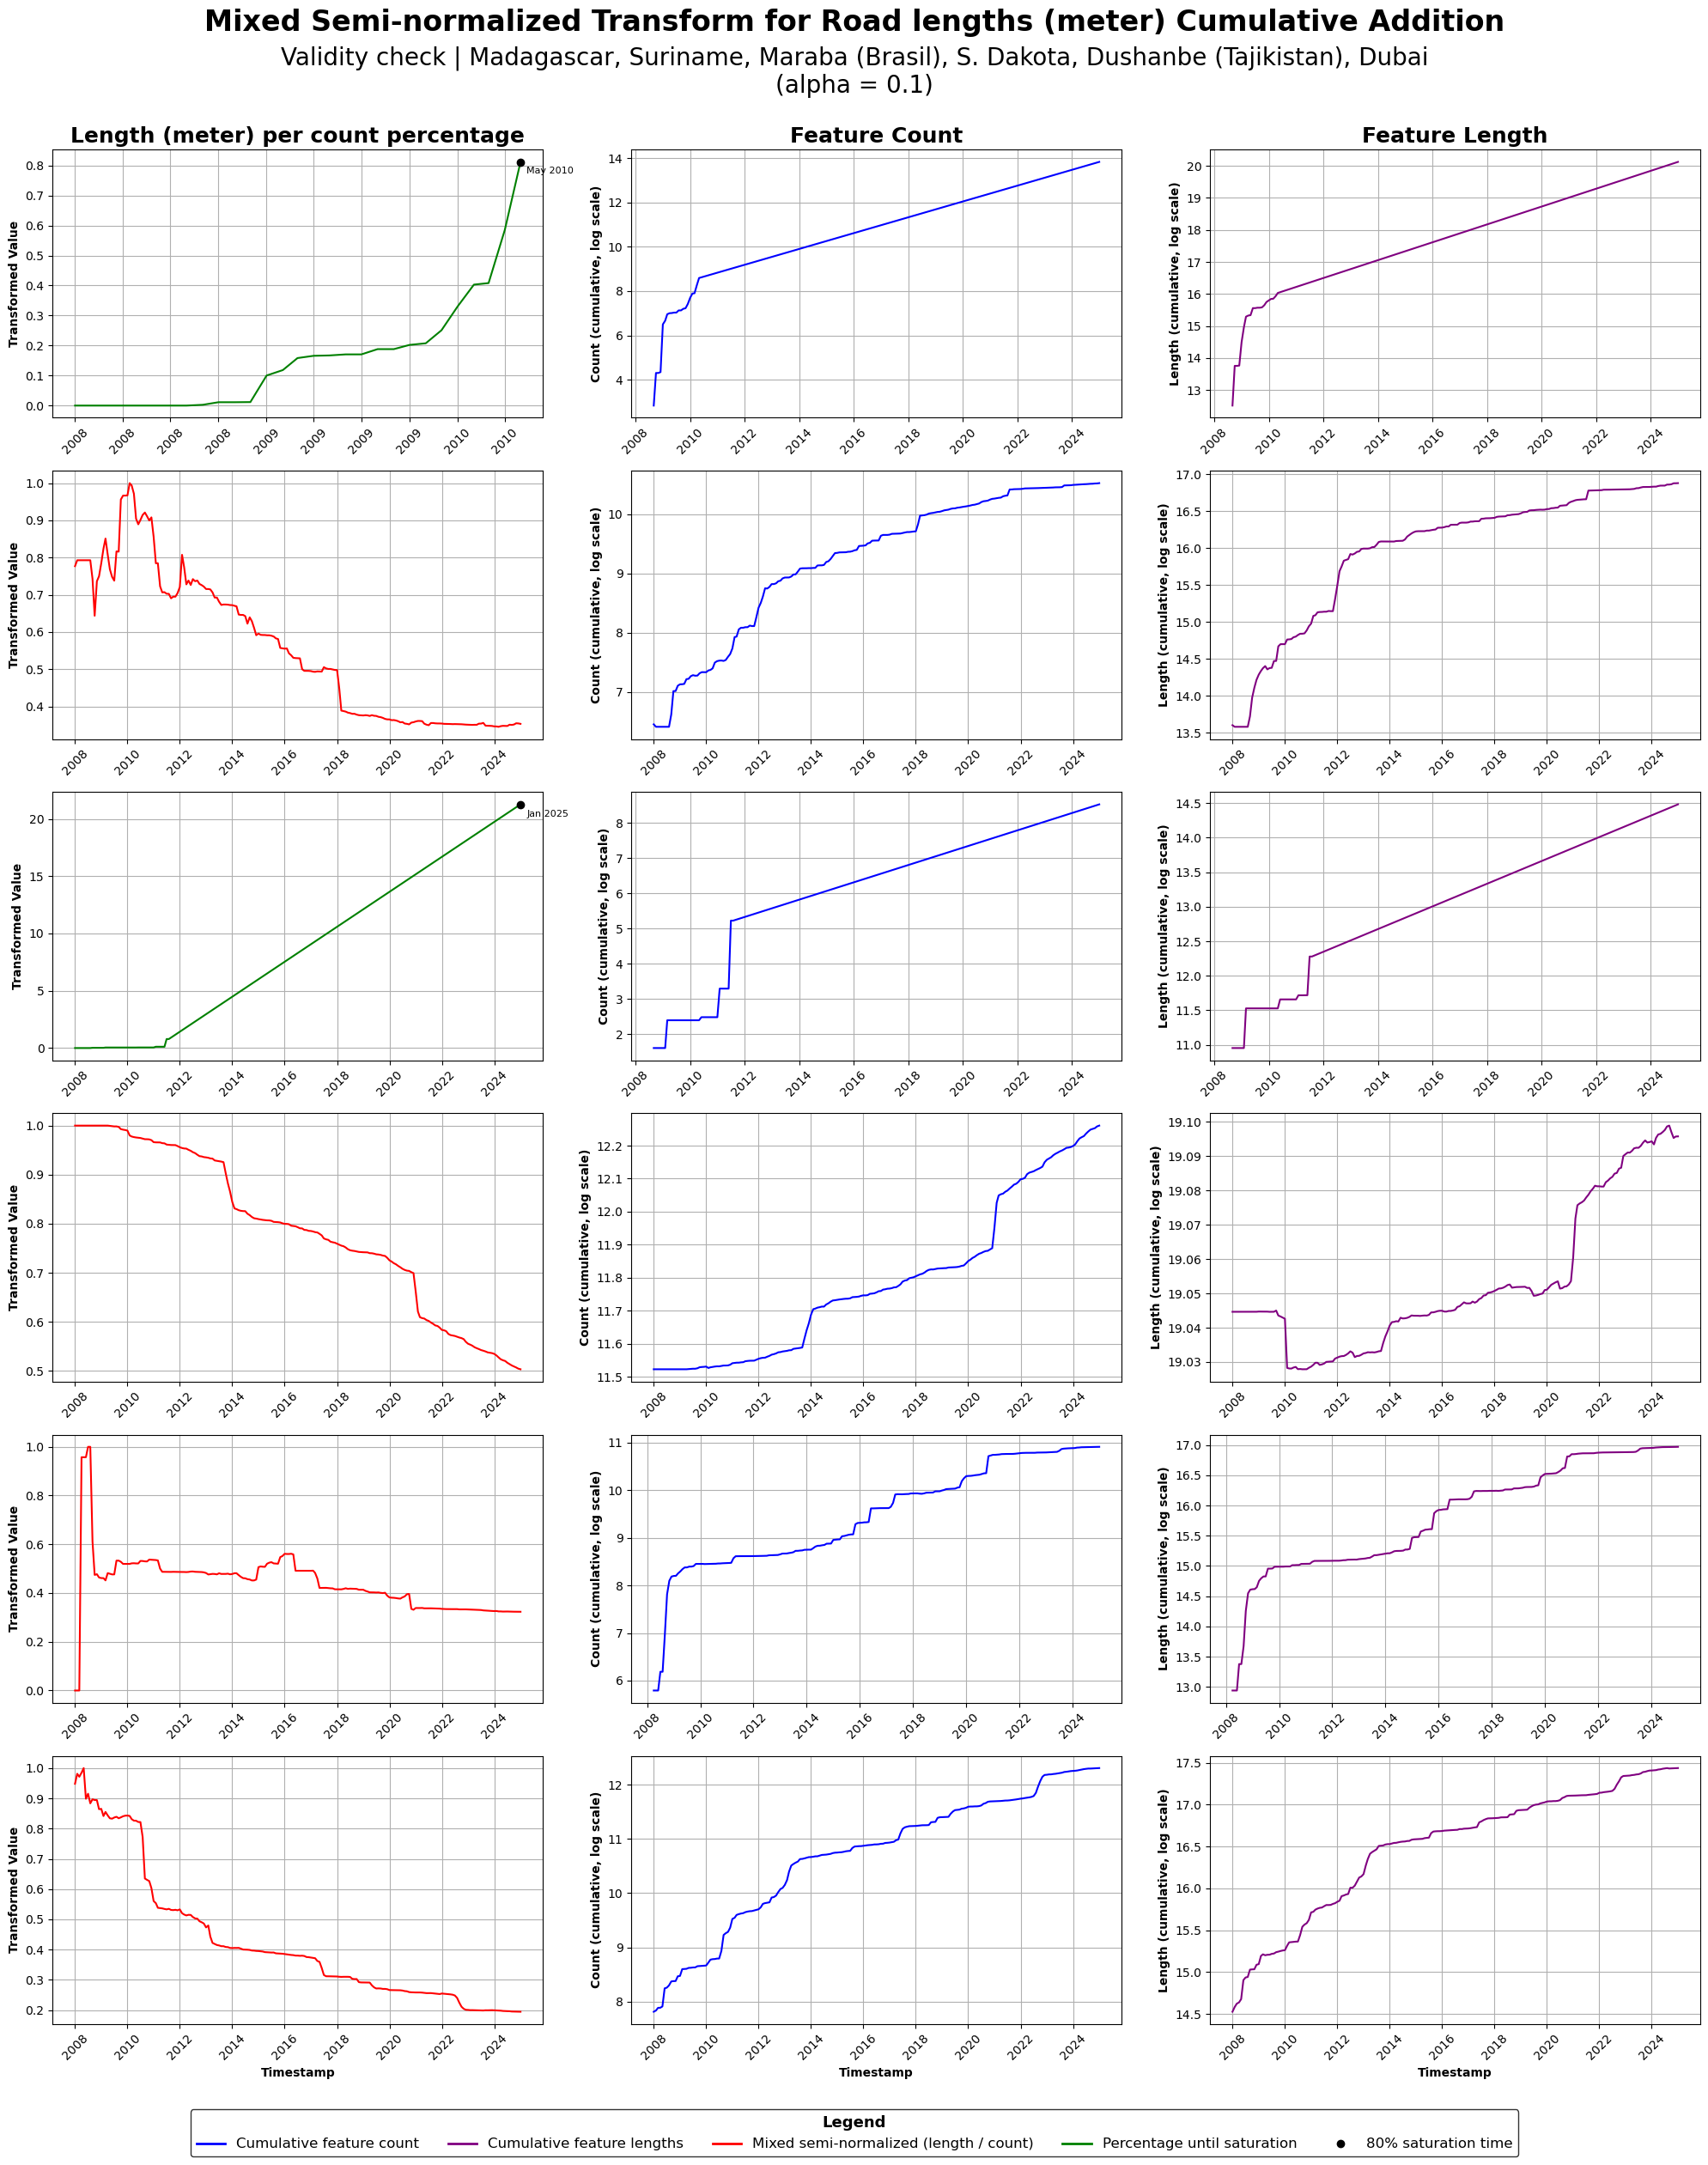

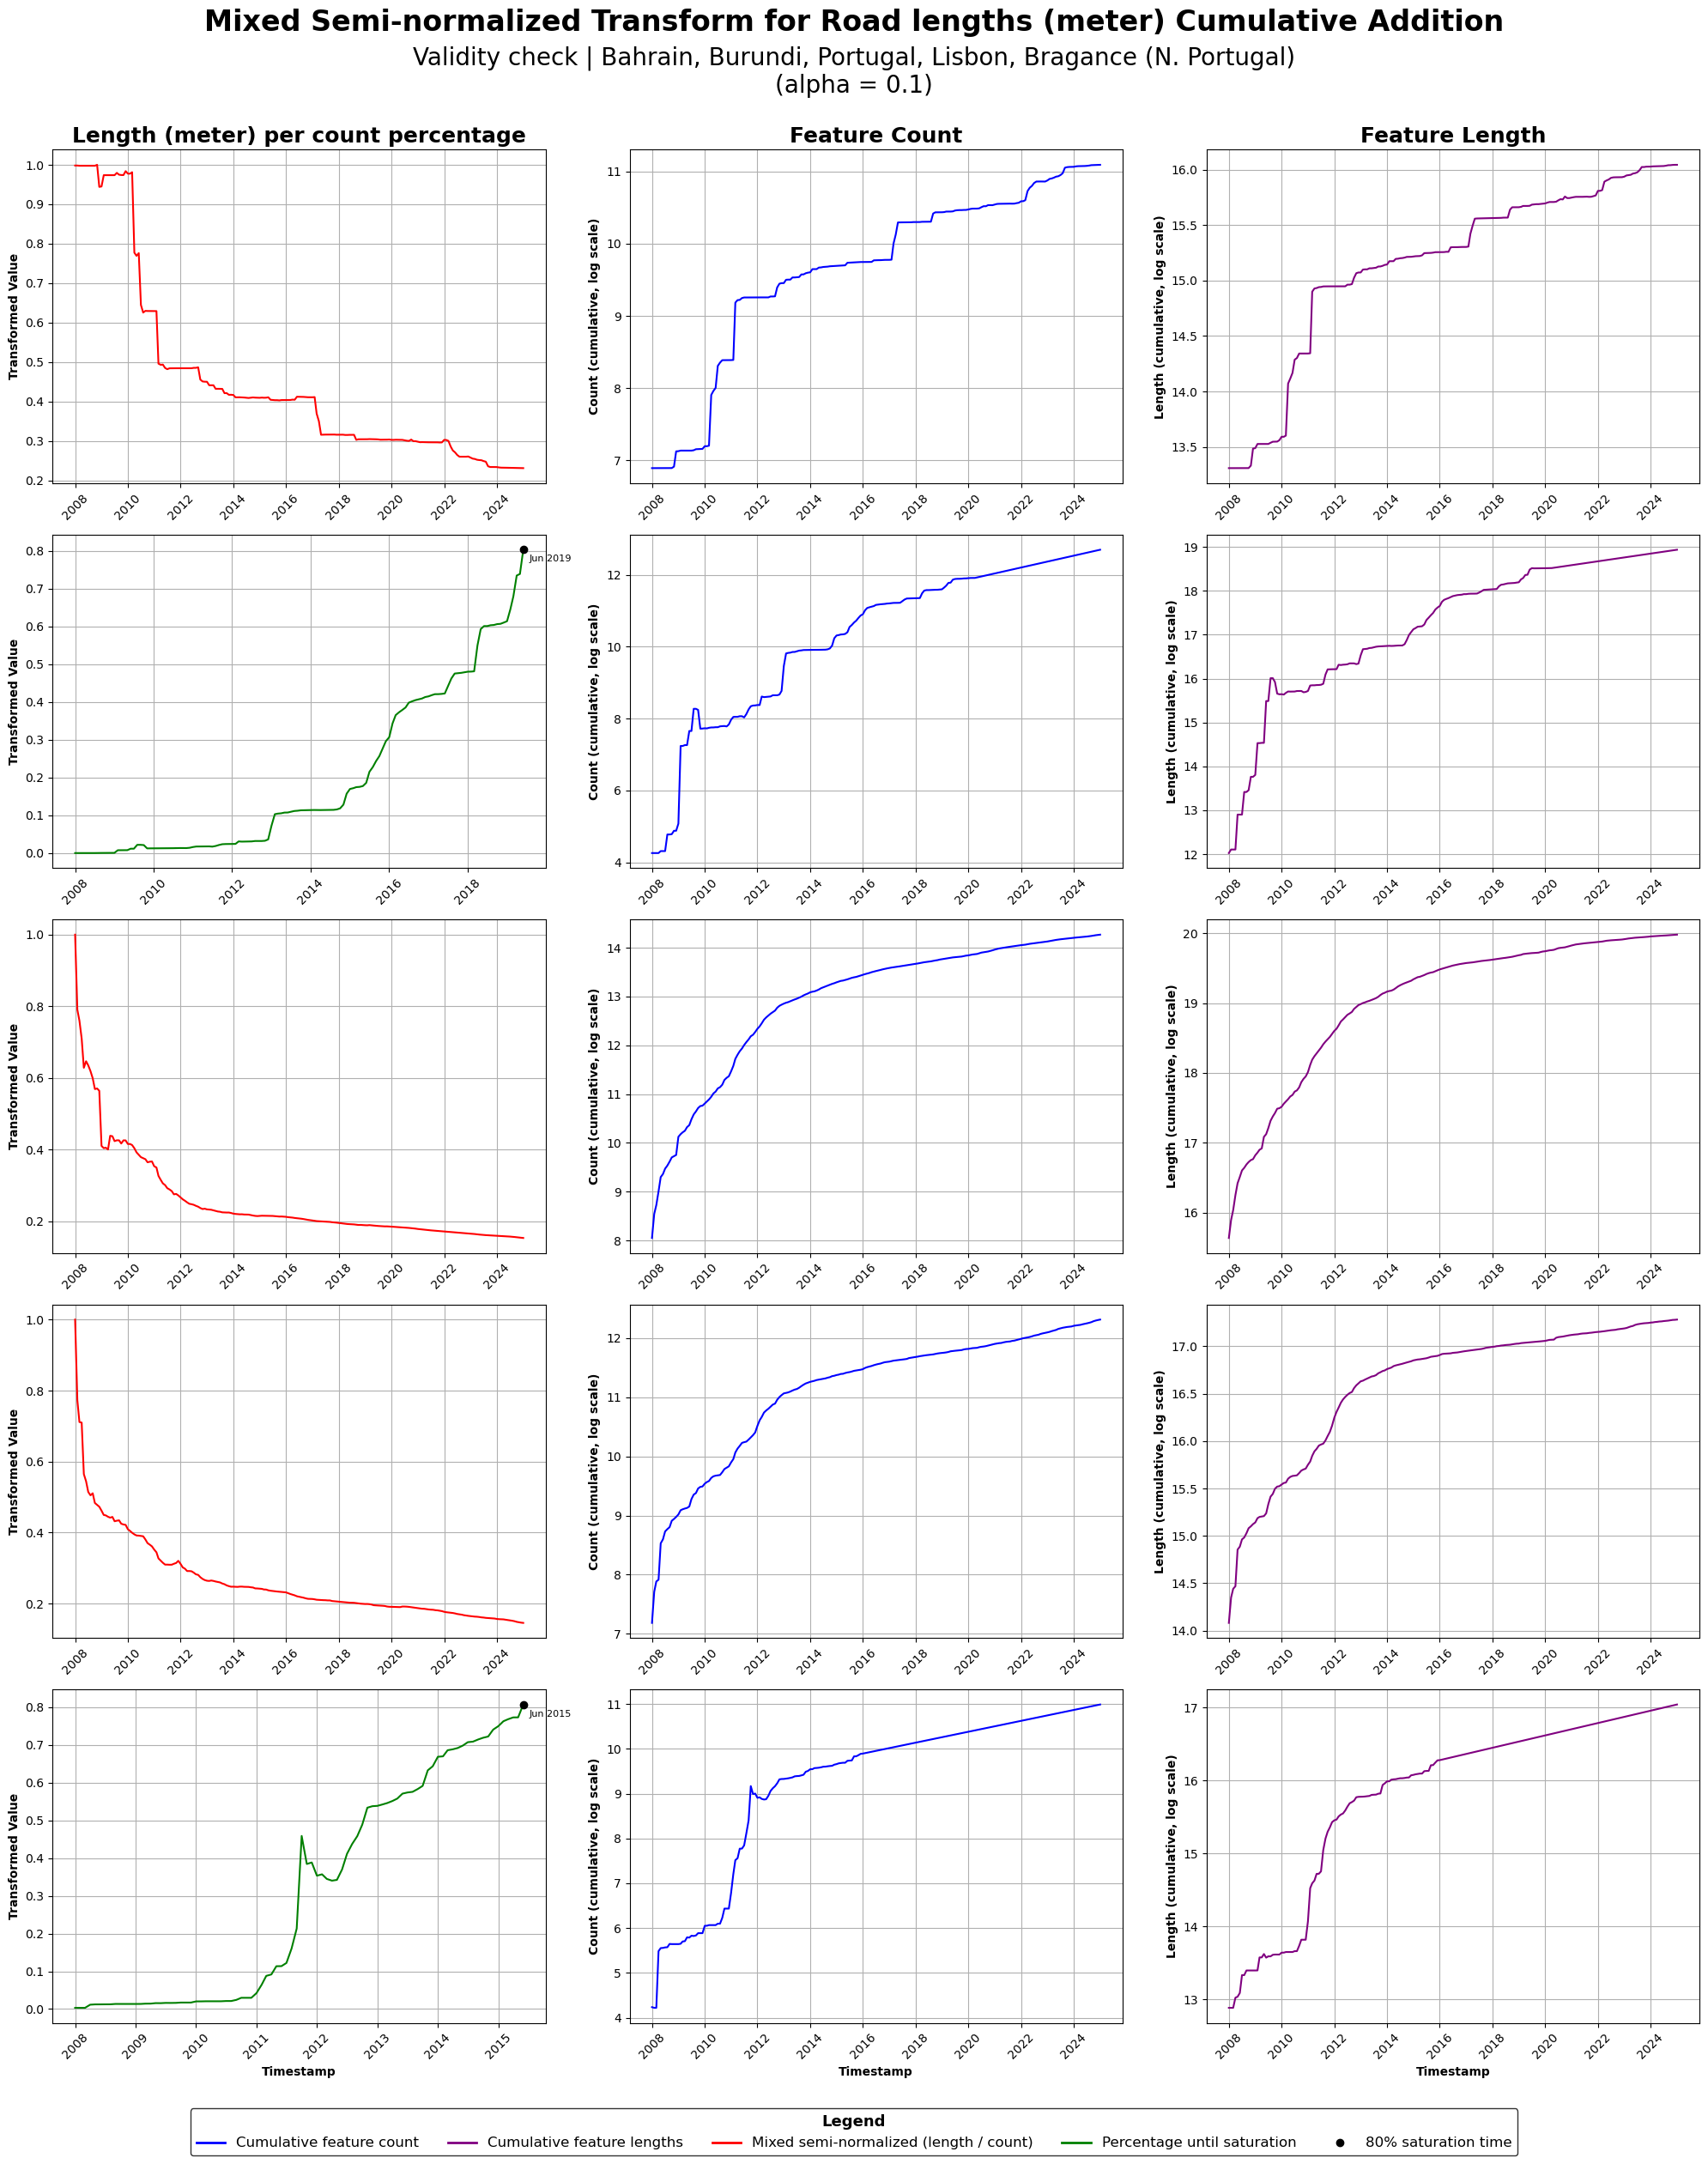

In [95]:
_ = generate_measure_sample_plot(roads_test[0:6], subtitle='Validity check | Strasburg, Paris, London, Iceland, Fiji, NZ\n(alpha = 0.1)').savefig(f'plots\\roads_measure_new_areas_1.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(roads_test[6:12], subtitle='Validity check | Madagascar, Suriname, Maraba (Brasil), S. Dakota, Dushanbe (Tajikistan), Dubai\n(alpha = 0.1)').savefig(f'plots\\roads_measure_new_areas_2.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(roads_test[12:], n=5, subtitle='Validity check | Bahrain, Burundi, Portugal, Lisbon, Bragance (N. Portugal)\n(alpha = 0.1)').savefig(f'plots\\roads_measure_new_areas_3.png', dpi=300, bbox_inches='tight')

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


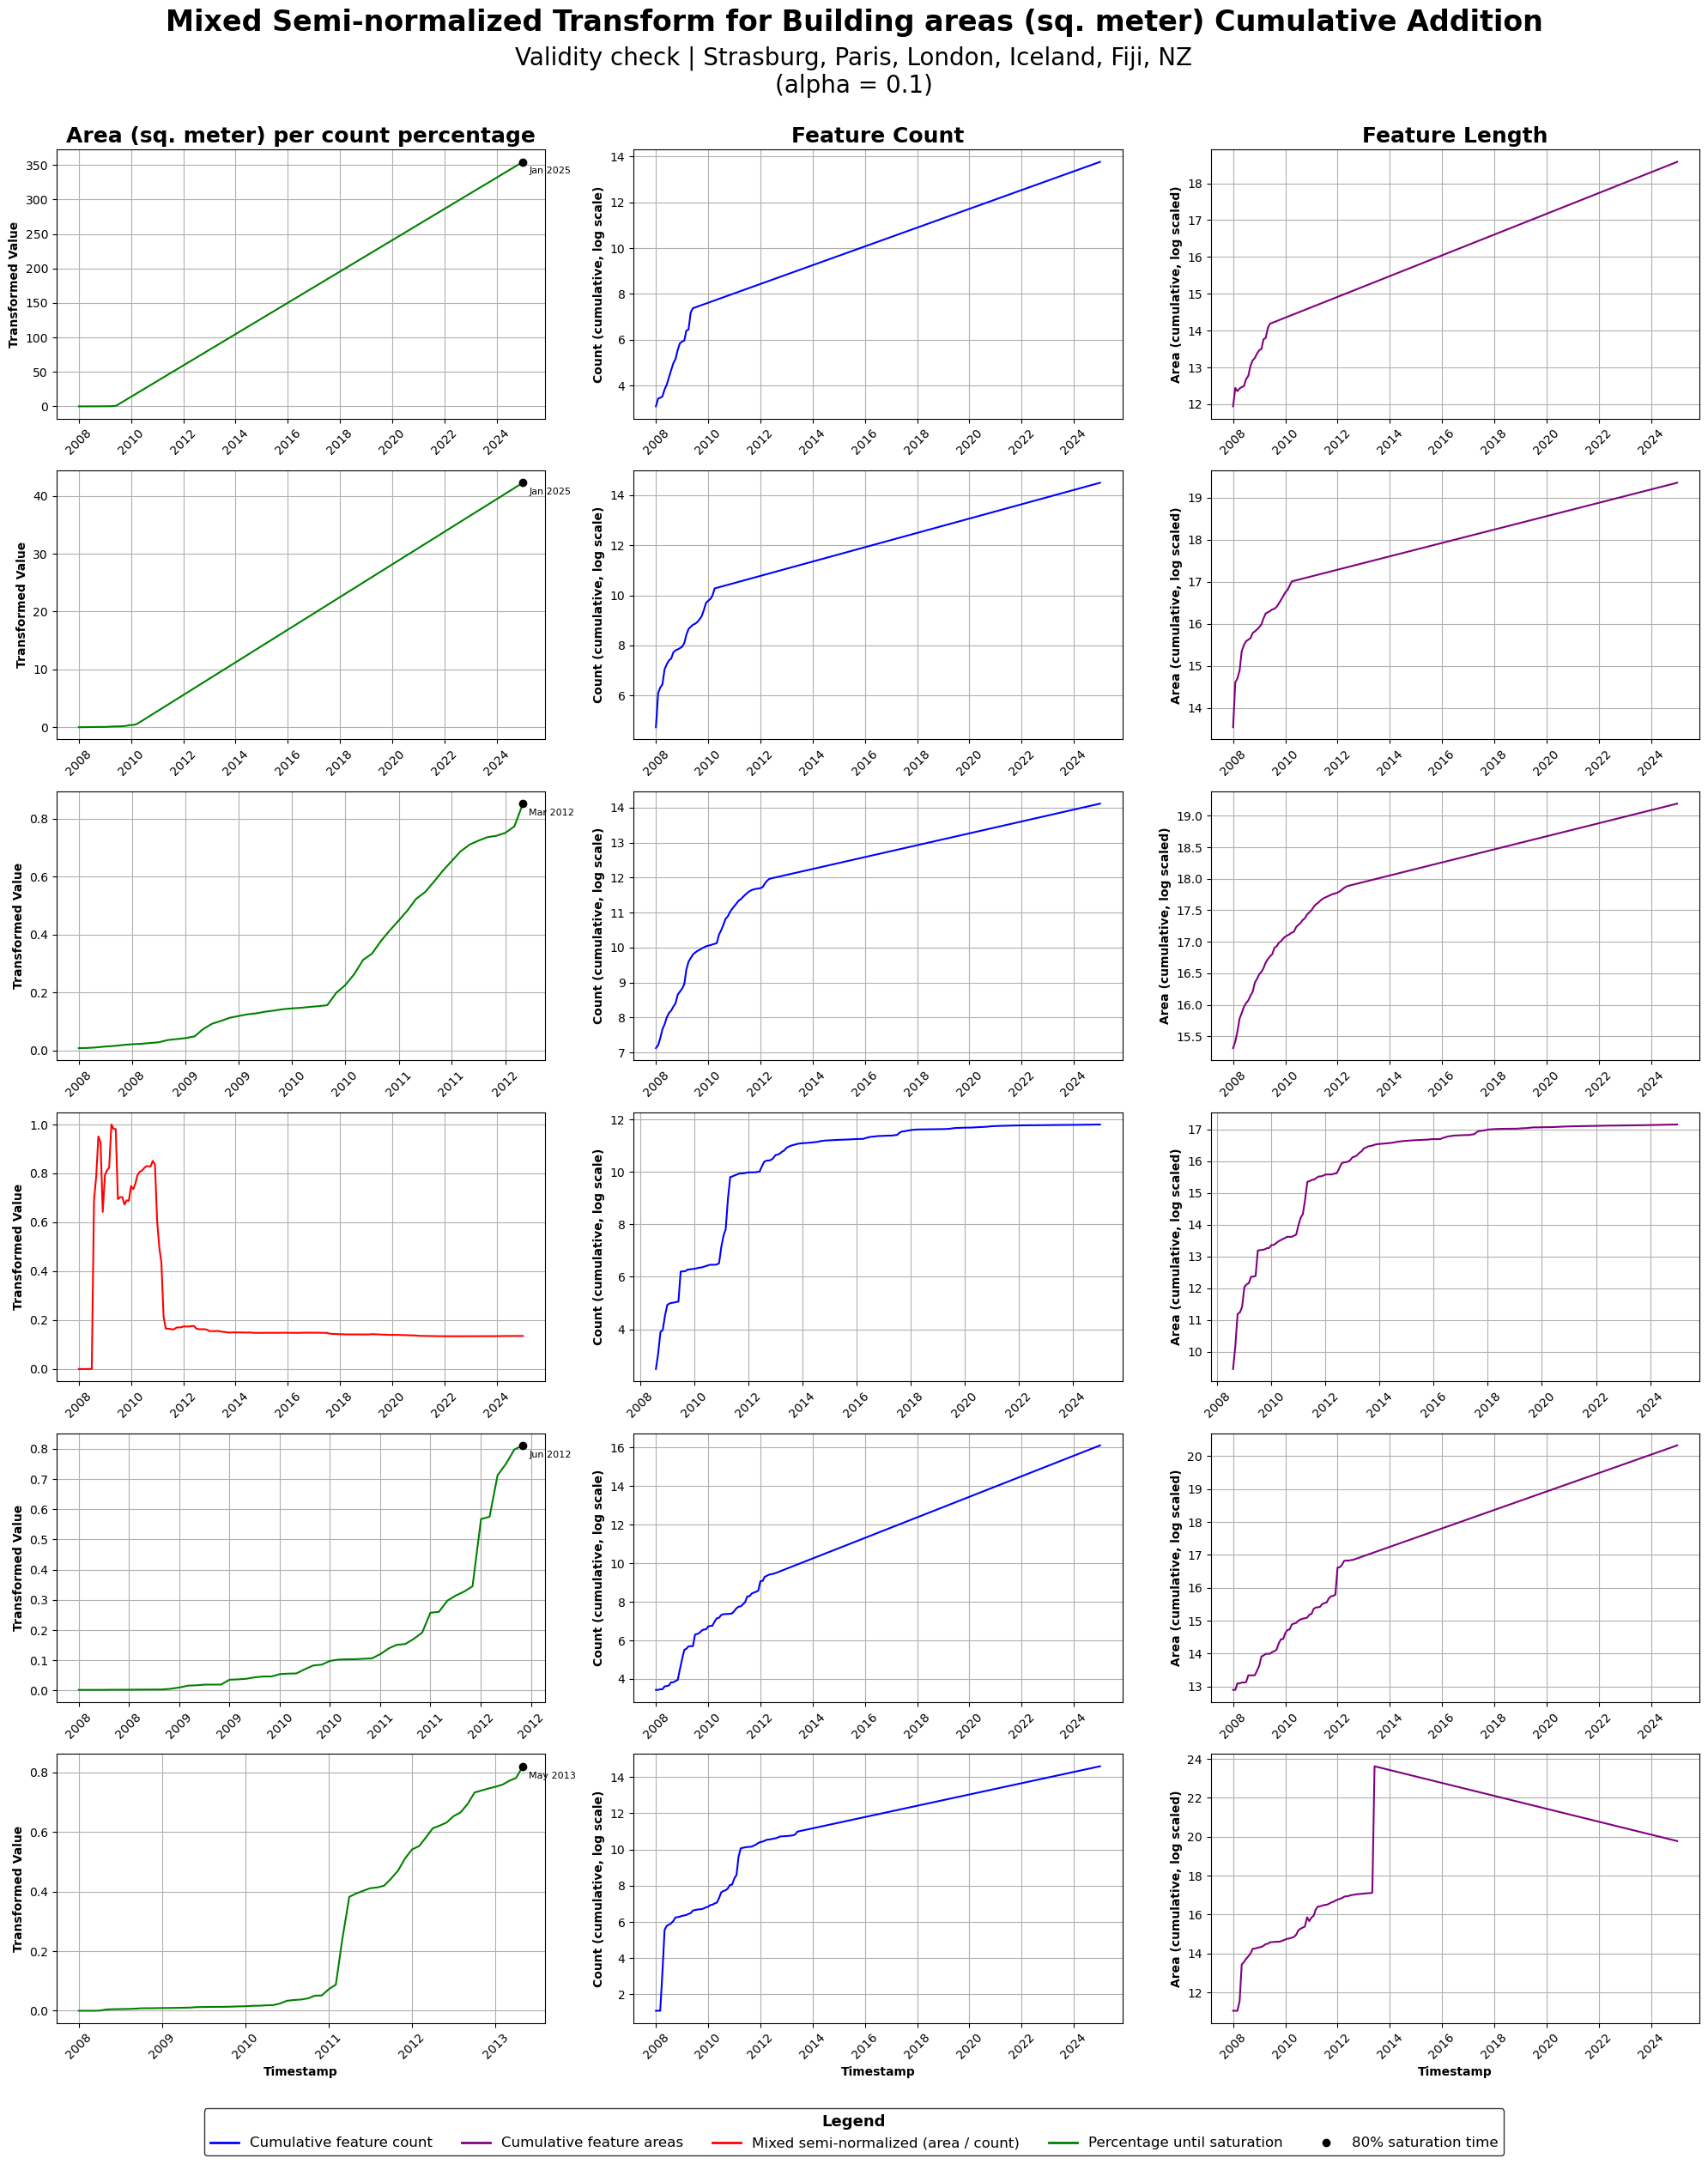

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


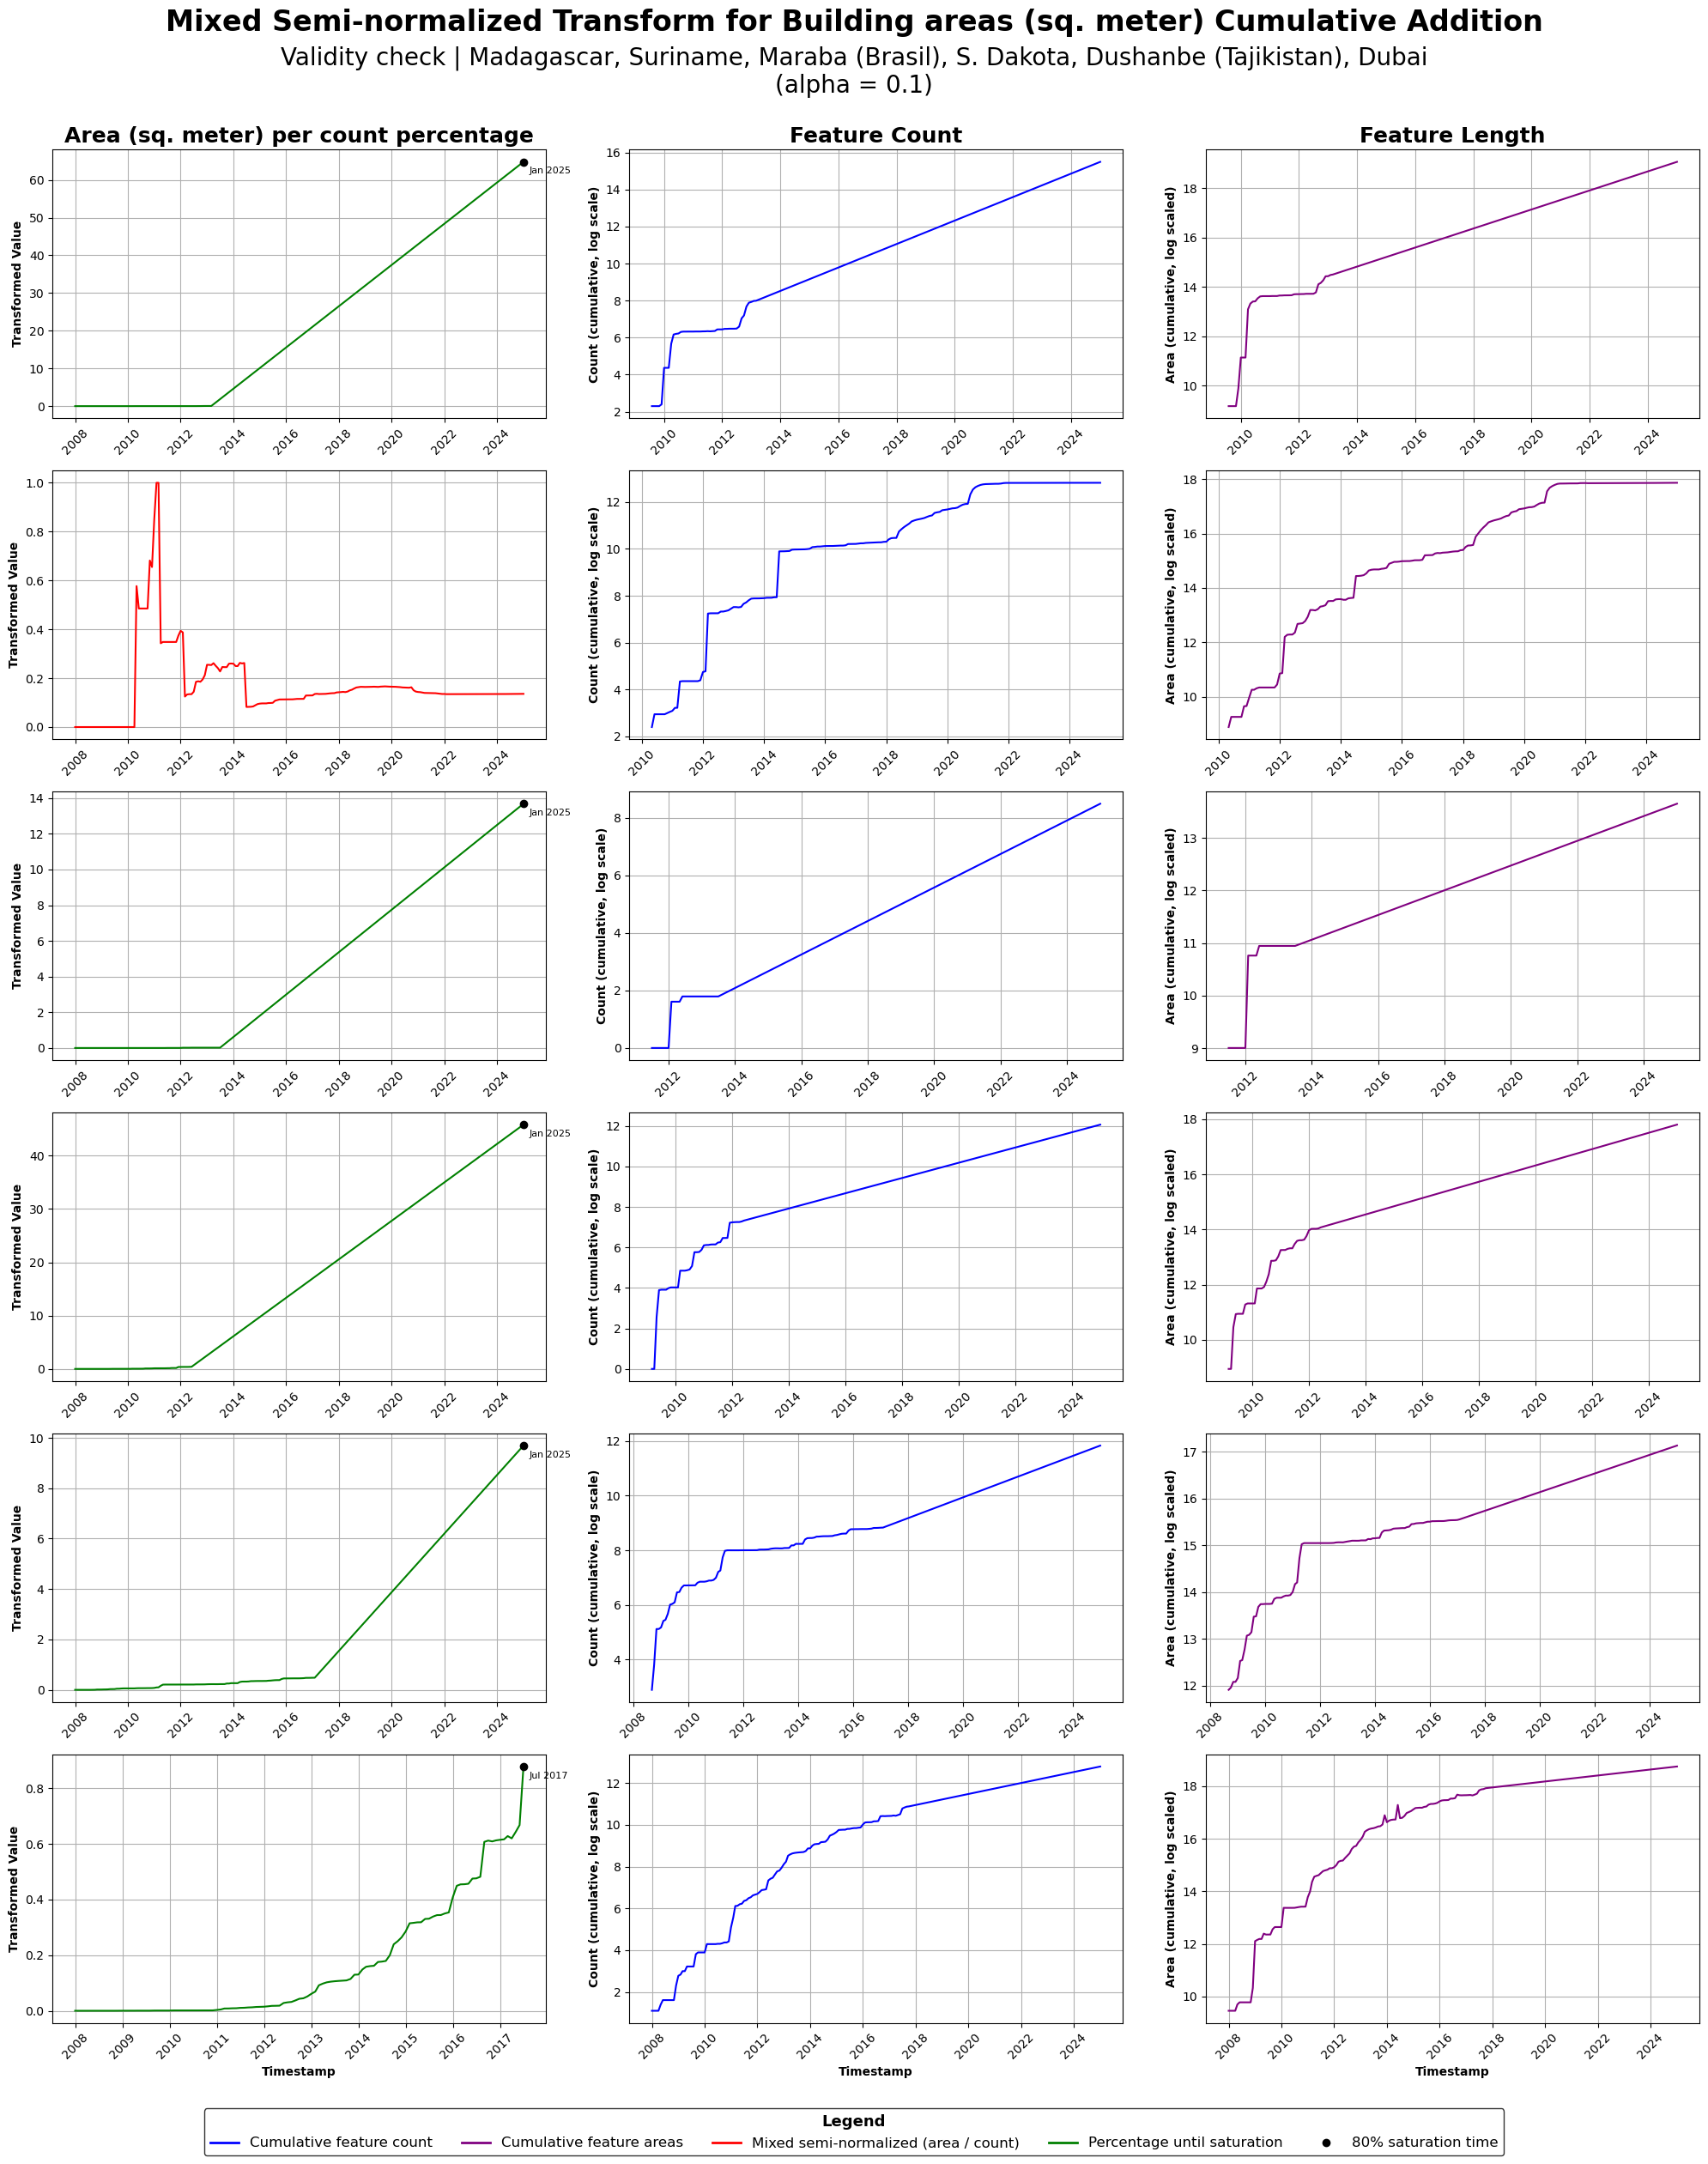

c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\eliya\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


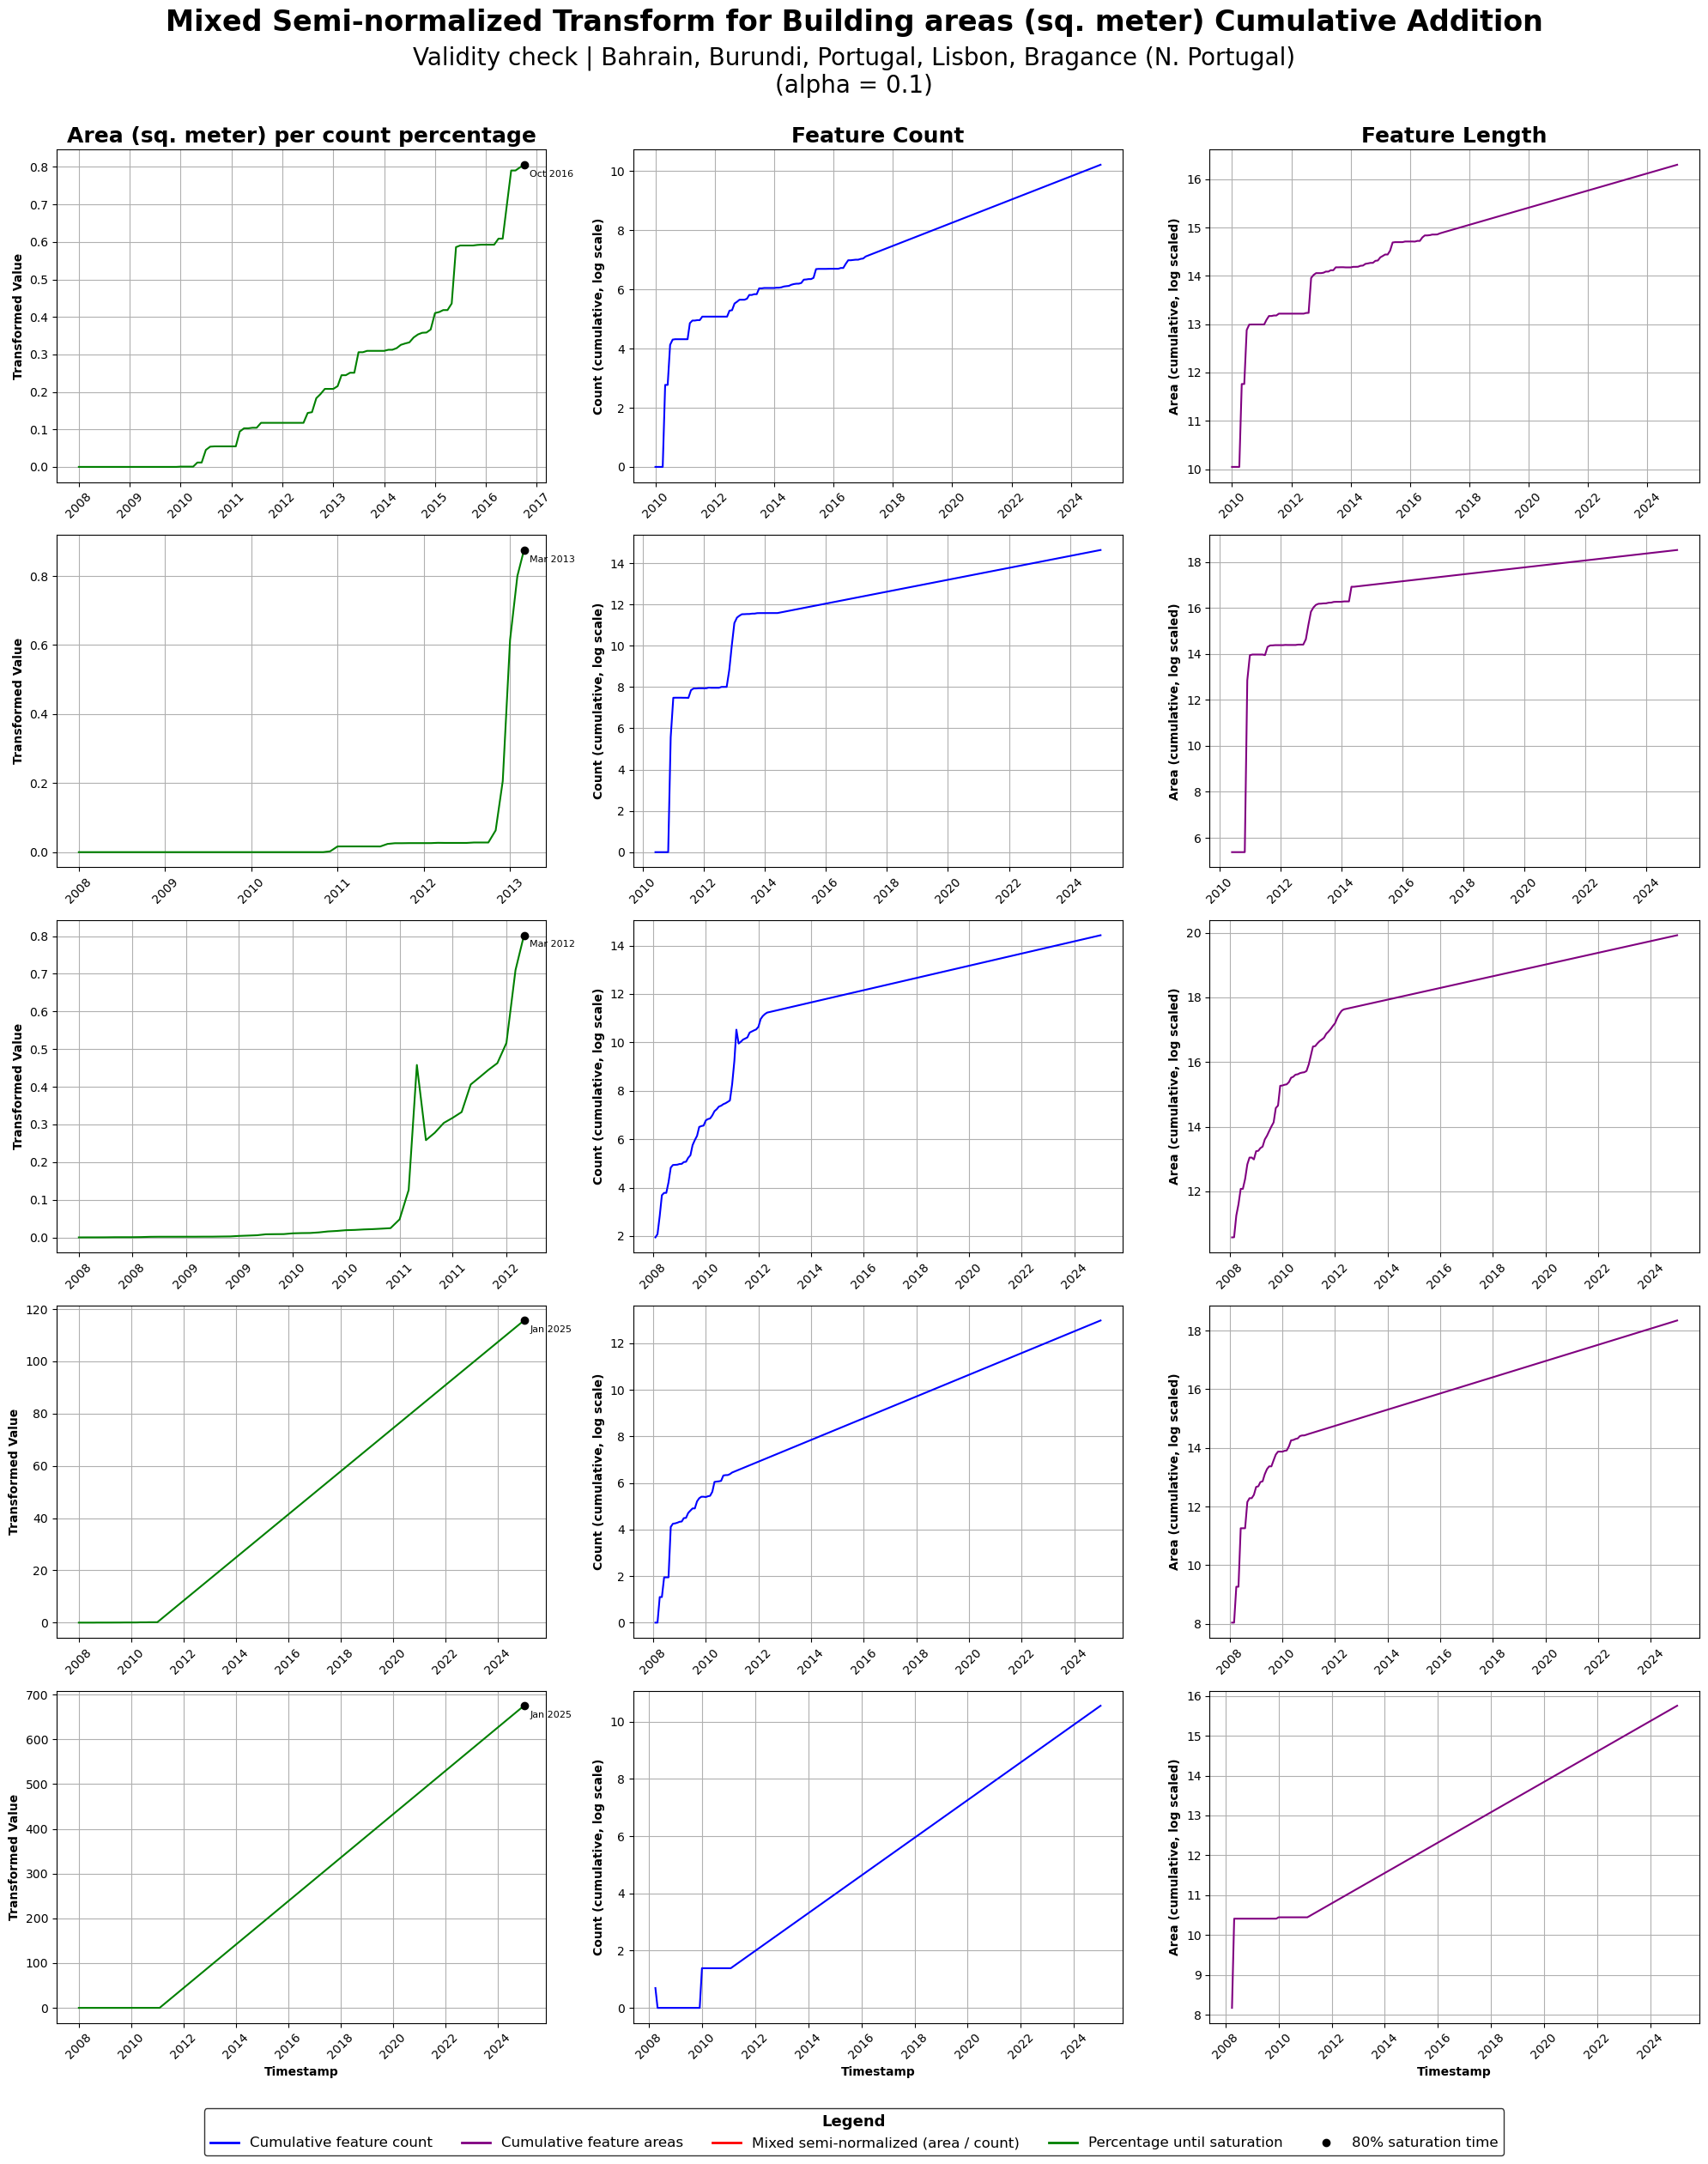

In [96]:
_ = generate_measure_sample_plot(bldgs_test[0:6], subtitle='Validity check | Strasburg, Paris, London, Iceland, Fiji, NZ\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_new_areas_1.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(bldgs_test[6:12], subtitle='Validity check | Madagascar, Suriname, Maraba (Brasil), S. Dakota, Dushanbe (Tajikistan), Dubai\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_new_areas_2.png', dpi=300, bbox_inches='tight')
_ = generate_measure_sample_plot(bldgs_test[12:], n=5, subtitle='Validity check | Bahrain, Burundi, Portugal, Lisbon, Bragance (N. Portugal)\n(alpha = 0.1)', length=False).savefig(f'plots\\buildings_measure_new_areas_3.png', dpi=300, bbox_inches='tight')